(MeanCurv)=
# Mean Curvature flow

Given a closed surface $\Gamma$, its mean curvature flow is described as the flow minimizing the functional
\begin{equation*}
\mathcal{E}(\Gamma) = \int_\Gamma \mathrm{d}s
\end{equation*}

It is thus the flow that moves in the direction that minimizes the area of the surface the most. It can be expressed as follows
\begin{equation*}
 \frac{\mathrm{d}\Gamma(t)}{\mathrm{d}t} = - \frac{\partial\mathcal{E}'(\Gamma)}{\partial\Gamma} = -\int_\Gamma Hw \mathrm{d}s
\end{equation*}

where $H$ is the surface mean curvature and $w$ is the **normal** velocity of the surface. To solve for the gradient flow using Finite Elements, what is usually done is to solve the PDE
\begin{equation*}
\frac{\mathrm{d}\vec{x}}{\mathrm{d}t} = -H\vec{\nu}
\end{equation*}

where $\vec{\nu}$ is the normal to the surface.

We show in the following the mean curvature flow of a circle. Due to the rotational symmetry of the circle, the equation have an exact solution given by the evolution of the radius $R(t)=\sqrt{R_0^2-2dt}$, where $d$ is the dimension of the problem. This allows us to describe its vector mean curvature, which is the second output of the algorithm, as 
\begin{equation*}
\vec{H(t)}=-\frac{d}{R(t)}\vec{\nu}
\end{equation*}

For $t=0.5$ in the case of the circle, the shape reduces to a point so we expect for the simulation to fail. The code is the following

------------------------------------------------------------
The mesh is a  2D mesh
The number of:
     vertices is:  388
     edges is:  1099
     faces is:  712
     facets is:  1099
     elements is:  712 ( = 0 if hypersurface)
Regions of co-dimension  0 :
 N.  1 region(s) called  default
Regions of co-dimension  1 :
 N.  2 region(s) called  boundary
Regions of co-dimension  2 :
 N.  2 region(s) called  default
------------------------------------------------------------ 

------------------------------------------------------------
This is a solver for the Willmore flow
It computes one step of it given the mesh
The algorithm is described in the article:
Stabilization for the mean curvature is implemented as in the article:
It uses conforming H-1 elements of order  1
Its parameters are
  - rhs - with type  <class 'ngsolve.fem.CoefficientFunction'>
  - stab - with type  <class 'ngsolve.fem.CoefficientFunction'>
  - sp_curv - with type  <class 'ngsolve.fem.CoefficientFunction'>
  - cl

Running Simulation...: 100%|████████████| 100/100 [00:00<00:00, 109.72it/s]

Simulation concluded successfully
----------
      Time  displacement  mean_curv
0    0.000      0.012499   0.002146
1    0.005      0.000104   0.027159
2    0.010      0.000106   0.027573
3    0.015      0.000108   0.027999
4    0.020      0.000109   0.028435
..     ...           ...        ...
96   0.480      0.007385   1.823441
97   0.485      0.009615   2.418250
98   0.490      0.013407   3.496555
99   0.495      0.021422   6.137438
100  0.500           NaN        NaN

[101 rows x 3 columns]


<function matplotlib.pyplot.show(close=None, block=None)>

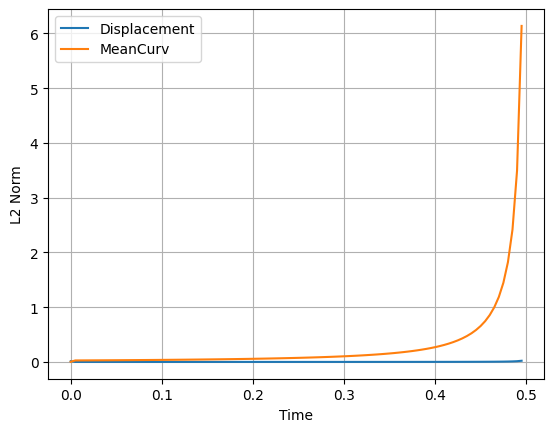

In [12]:
from ngsolve import *
from ngsolve.webgui import Draw
from netgen.occ import *   # Opencascade for geometry modeling
import pandas as pd
import matplotlib.pyplot as plt

from cosmos.utils.generate_surface_meshes import generate_circle

R = 1
mesh, _ = generate_circle(maxh = 0.1, R=R)

'''
Definition of the time parameters
'''
T = 0.5
dt = Parameter(0.005)
t = Parameter(0)

## Exact solution
R_ex = sqrt(R**2 - 2*t)
H_ex = -1/R_ex
n_ex = CF((x,y))/Norm(CF((x,y)))
displ_ex = n_ex*(sqrt(R**2 - 2*t) - sqrt(R**2 - 2*(t-dt)))

'''
Definition of the simulation
'''
from cosmos.solvers.simulation import MovingSimulation
simulation = MovingSimulation(mesh=mesh, dt=dt, t=t, T=T, verbose = 1)

# Adding Willmore flow to the internal square
from cosmos.solvers.mean_curvature import MeanCurvatureSolver
displ_solver = MeanCurvatureSolver()
displ_solver.SaveSolution(folderpath = './mean_curvature/', filename = 'circle', n_steps = 10)
displ_solver.ComputeError(folderpath = './mean_curvature/', filename = 'circle_errs', norm = 'L2', ex_sol = [displ_ex, n_ex*H_ex])

# Adding the Willmore flow motion to the overall simulation
simulation.AddMotionSolver(displ_solver)
def displ():
    return displ_solver.get_solution()[0]
simulation.AddMotion(function=displ, domain = '.*')

simulation.run()


import pandas as pd

file_path = "./mean_curvature/circle_errs"

# Read the CSV into a DataFrame
df = pd.read_csv(file_path)

print(df)

import matplotlib.pyplot as plt
plt.plot(df['Time'], df['displacement'], label = 'Displacement')
plt.plot(df['Time'], df['mean_curv'], label = 'MeanCurv')
plt.xlabel('Time')
plt.ylabel('L2 Norm')
plt.grid()
plt.legend()
plt.show

We can try the same for the mean curvature flow of a sphere (no volume elements). This time the singularity time is at $t=0.25$.

------------------------------------------------------------
The mesh is a  3D mesh
! The mesh is also an hypersurface embedded in  3D !
The number of:
     vertices is:  1358
     edges is:  4068
     faces is:  2712
     facets is:  2712
     elements is:  0 ( = 0 if hypersurface)
Regions of co-dimension  0 :
 N.  1 region(s) called  default
Regions of co-dimension  1 :
 N.  1 region(s) called  default
------------------------------------------------------------ 

------------------------------------------------------------
This is a solver for the Willmore flow
It computes one step of it given the mesh
The algorithm is described in the article:
Stabilization for the mean curvature is implemented as in the article:
It uses conforming H-1 elements of order  1
Its parameters are
  - rhs - with type  <class 'ngsolve.fem.CoefficientFunction'>
  - stab - with type  <class 'ngsolve.fem.CoefficientFunction'>
  - sp_curv - with type  <class 'ngsolve.fem.CoefficientFunction'>
  - clamped_bnd 

Running Simulation...: 100%|███████████████| 25/25 [00:12<00:00,  2.06it/s]

Simulation concluded successfully
----------
    Time  displacement  mean_curv
0   0.00      0.070123   0.215148
1   0.01      0.002582   0.330052
2   0.02      0.002712   0.346564
3   0.03      0.002871   0.365985
4   0.04      0.003049   0.387503
5   0.05      0.003245   0.411291
6   0.06      0.003463   0.437676
7   0.07      0.003706   0.467075
8   0.08      0.003979   0.500002
9   0.09      0.004285   0.537096
10  0.10      0.004633   0.579154
11  0.11      0.005030   0.627190
12  0.12      0.005486   0.682506
13  0.13      0.006016   0.746807
14  0.14      0.006637   0.822365
15  0.15      0.007374   0.912279
16  0.16      0.008261   1.020891
17  0.17      0.009346   1.154478
18  0.18      0.010699   1.322490
19  0.19      0.012432   1.539883
20  0.20      0.014724   1.831943
21  0.21      0.017896   2.245503
22  0.22      0.022581   2.879709
23  0.23      0.030288   3.995629
24  0.24      0.046037   6.656140
25  0.25           NaN        NaN


<function matplotlib.pyplot.show(close=None, block=None)>

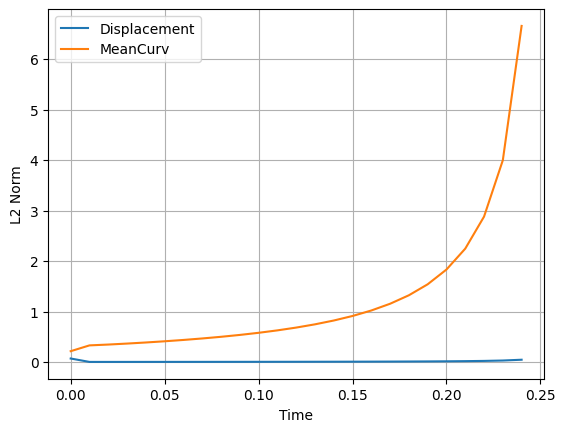

In [10]:
from ngsolve import *
from ngsolve.webgui import Draw
from netgen.occ import *   # Opencascade for geometry modeling
import pandas as pd
import matplotlib.pyplot as plt

from cosmos.utils.generate_surface_meshes import generate_sphere

R = 1
mesh, _ = generate_sphere(maxh = 0.1, R=R)

'''
Definition of the time parameters
'''
T = 0.25
dt = Parameter(0.01)
t = Parameter(0)

## Exact solution
R_ex = sqrt(R**2 - 4*t)
H_ex = -2/R_ex
n_ex = CF((x,y,z))/Norm(CF((x,y,z)))
displ_ex = n_ex*(sqrt(R**2 - 4*t) - sqrt(R**2 - 4*(t-dt)))

'''
Definition of the simulation
'''
from cosmos.solvers.simulation import MovingSimulation
simulation = MovingSimulation(mesh=mesh, dt=dt, t=t, T=T, verbose = 1)

# Adding Willmore flow to the internal square
from cosmos.solvers.mean_curvature import MeanCurvatureSolver
displ_solver = MeanCurvatureSolver()
displ_solver.SaveSolution(folderpath = './mean_curvature/', filename = 'sphere', n_steps = 10)
displ_solver.ComputeError(folderpath = './mean_curvature/', filename = 'sphere_errs', norm = 'L2', ex_sol = [displ_ex, n_ex*H_ex])

# Adding the Willmore flow motion to the overall simulation
simulation.AddMotionSolver(displ_solver)
def displ():
    return displ_solver.get_solution()[0]
simulation.AddMotion(function=displ, domain = '.*')

simulation.run()

# displ_solver.draw_solution()


import pandas as pd

file_path = "./mean_curvature/sphere_errs"

# Read the CSV into a DataFrame
df = pd.read_csv(file_path)

print(df)

import matplotlib.pyplot as plt
plt.plot(df['Time'], df['displacement'], label = 'Displacement')
plt.plot(df['Time'], df['mean_curv'], label = 'MeanCurv')
plt.xlabel('Time')
plt.ylabel('L2 Norm')
plt.grid()
plt.legend()
plt.show